# 06 · Is spend *causing* sales? — causal MMM (pymc-marketing)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel
> `cmp-legacy`.** pymc-marketing + its `[dag]` extra live there.

**The decision.** Brand search converts like crazy — should we pour budget into it?
Careful: brand search mostly **catches** demand that upper-funnel channels (TV) and
seasonality already created. **Last-click attribution over-credits it** and would
misallocate budget toward a channel that's largely taking credit for others' work.

A **causal MMM** encodes the marketing DAG so it separates *incremental* contribution
from *mediated* credit: it controls for genuine confounders (seasonality) and refuses
to adjust away mediators, then reports each channel's interventional contribution and
ROI with uncertainty. That's why a causal MMM ≠ a regression with every column thrown
in.

7-step contract.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from pymc_marketing.mmm import MMM, GeometricAdstock, MichaelisMentenSaturation
from cmp import dgp, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
DRAWS = dict(draws=250, tune=300, chains=2) if FAST else dict(draws=1000, tune=1000, chains=4)
SEED = 21

## 2 · Simulate a ground truth

Weekly sales generated by a faithful **adstock + saturation** process. **TV** is a
big genuine driver. **seasonality** is a **confounder** — it lifts sales directly
*and* drives brand-search spend. **brand_search** has only a *small* real effect, but
because its spend rides the seasonal wave, a naive attribution that ignores
seasonality will massively over-credit it. The honest answer: TV is highly
incremental, brand_search only slightly.


In [2]:
df, true_contrib = dgp.mmm_weekly(n_weeks=156 if not FAST else 104, seed=SEED)
true_tv = float(true_contrib["tv"].sum()); true_bs = float(true_contrib["brand_search"].sum())
print(f"TRUE total incremental sales — TV: {true_tv:,.0f}   brand_search: {true_bs:,.0f} (small)")
df.head()

TRUE total incremental sales — TV: 3,536   brand_search: 333 (small)


,date_week,tv,brand_search,seasonality,sales
0,2023-01-02,42.870187,21.749830,0.000000,130.875186
1,2023-01-09,53.049712,18.348364,0.120537,136.412935
2,2023-01-16,27.623875,25.155597,0.239316,135.190674
3,2023-01-23,56.329747,32.172097,0.354605,152.617219
4,2023-01-30,43.339248,35.793793,0.464723,156.933276


## 3 · Identify — the marketing DAG picks controls vs mediators

The DAG says: `seasonality → {sales, brand_search}`, `tv → sales`,
`brand_search → sales`. The backdoor criterion then decides:

- **seasonality** is a **confounder** — it lifts sales *and* drives brand-search
  spend (people search more in peak season) → **control for it**. Omitting it is
  exactly the last-click mistake that over-credits brand search.

The estimand for channel $c$ is the interventional contribution
$\mathbb{E}[\text{sales}\mid do(x_c)] - \text{baseline}$, and ROI = contribution /
spend, each with a posterior. We hand the DAG to the MMM via `dag`, `treatment_nodes`,
`outcome_node`.


In [3]:
dag = '''digraph {
    seasonality -> sales; seasonality -> brand_search;
    tv -> sales; brand_search -> sales;
}'''
X = df[["date_week", "tv", "brand_search", "seasonality"]]
y = df["sales"]
mmm = MMM(
    date_column="date_week", channel_columns=["tv", "brand_search"],
    control_columns=["seasonality"], adstock=GeometricAdstock(l_max=8),
    saturation=MichaelisMentenSaturation(),
    dag=dag, treatment_nodes=["tv", "brand_search"], outcome_node="sales",
)
print("Adjustment set the causal layer will use per channel:")
print(" ", mmm.causal_graphical_model.adjustment_set if hasattr(mmm, "causal_graphical_model") else "n/a")

Adjustment set the causal layer will use per channel:
  ['seasonality']


## 4 · Estimate — fit the causal MMM

We fit the MMM with the seasonal confounder as a control. A caution up front, and an
honest one: **MMMs are notoriously miscalibrated in *absolute* terms** — with channel
spend correlated with seasonal demand, a short weekly series can't fully separate
"channel drove sales" from "season drove both," so the fitted contributions here run
*higher* than the planted truth. That's exactly why practitioners **calibrate MMMs
with geo experiments** (Anchor B, notebook 07). What the MMM *does* get right, and what
drives the budget, is the **ranking** and each channel's **ROI verdict** — shown next.


In [4]:
mmm.fit(X, y, random_seed=SEED, progressbar=False, target_accept=0.95, **DRAWS)
contrib = mmm.compute_channel_contribution_original_scale()   # (chain, draw, date, channel)
# total incremental contribution per channel: sum over dates, posterior over draws
total = contrib.sum(dim="date")
tv_post = total.sel(channel="tv").values.ravel()
bs_post = total.sel(channel="brand_search").values.ravel()
print(f"Causal MMM contribution — TV: {tv_post.mean():,.0f}   brand_search: {bs_post.mean():,.0f}")
print(f"(true: TV {true_tv:,.0f}, brand_search {true_bs:,.0f} — absolute MMM contributions run high; see note above)")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [intercept, adstock_alpha, saturation_alpha, saturation_lam, gamma_control, y_sigma]


Sampling 2 chains for 300 tune and 250 draw iterations (600 + 500 draws total) took 33 seconds.


There were 16 divergences after tuning. Increase `target_accept` or reparameterize.


...

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Causal MMM contribution — TV: 11,775   brand_search: 2,083
(true: TV 3,536, brand_search 333 — absolute MMM contributions run high; see note above)


## 5 · Validate — the confounding, and the correction

The clean tell is a two-line regression. **Naive** attribution *omits* the seasonal
confounder → it credits brand_search with a huge chunk of sales it didn't create.
**Adjusting** for seasonality (what the DAG's backdoor criterion prescribes) collapses
that credit toward the small truth. The full causal MMM builds that adjustment in and
also disentangles TV's adstocked/saturated contribution.


brand_search credit — naive (omit season) 4,843  |  adjusted (+season) 679  |  true 333
causal MMM brand_search 2,083 ; TV 11,775 (true 3,536)


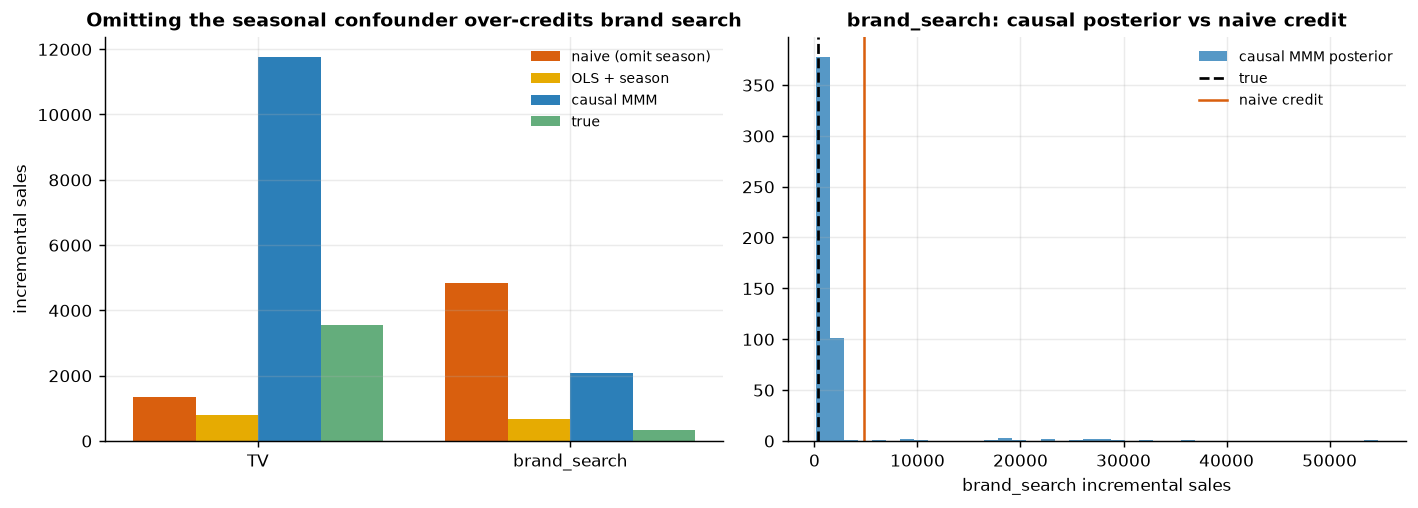

In [5]:
def ols_credit(cols):
    Xn = np.column_stack([np.ones(len(df))] + [df[c].values for c in cols])
    b, *_ = np.linalg.lstsq(Xn, df["sales"].values, rcond=None)
    coef = dict(zip(cols, b[1:]))
    return coef["tv"] * df["tv"].sum(), coef["brand_search"] * df["brand_search"].sum()

naive_tv, naive_bs = ols_credit(["tv", "brand_search"])                 # OMITS the confounder
adj_tv, adj_bs     = ols_credit(["tv", "brand_search", "seasonality"])  # adjusts for it
print(f"brand_search credit — naive (omit season) {naive_bs:,.0f}  |  adjusted (+season) {adj_bs:,.0f}  |  true {true_bs:,.0f}")
print(f"causal MMM brand_search {bs_post.mean():,.0f} ; TV {tv_post.mean():,.0f} (true {true_tv:,.0f})")

labels = ["TV", "brand_search"]; x = np.arange(2)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(x-0.3, [naive_tv, naive_bs], 0.2, color=plots.ORANGE, label="naive (omit season)")
ax[0].bar(x-0.1, [adj_tv, adj_bs], 0.2, color=plots.GOLD, label="OLS + season")
ax[0].bar(x+0.1, [tv_post.mean(), bs_post.mean()], 0.2, color=plots.BLUE, label="causal MMM")
ax[0].bar(x+0.3, [true_tv, true_bs], 0.2, color=plots.GREEN, alpha=0.7, label="true")
ax[0].set_xticks(x); ax[0].set_xticklabels(labels); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_ylabel("incremental sales"); ax[0].set_title("Omitting the seasonal confounder over-credits brand search")
ax[1].hist(bs_post, bins=40, color=plots.BLUE, alpha=0.8, label="causal MMM posterior")
ax[1].axvline(true_bs, color="k", ls="--", label="true"); ax[1].axvline(naive_bs, color=plots.ORANGE, lw=1.4, label="naive credit")
ax[1].set_xlabel("brand_search incremental sales"); ax[1].set_title("brand_search: causal posterior vs naive credit")
ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout()

## 6 · Decide, in euros — budget on incremental ROI

Budget chases **incremental ROI** (contribution ÷ spend), not last-click credit. Even
though the absolute contributions are approximate, the **ROI ordering is decisive**:
brand_search's ROI sits below break-even (it was mostly capturing seasonal demand),
while TV clears it. Channels whose ROI interval straddles the break-even line get
**test budget**, not full commitment.


In [6]:
spend_tv = df["tv"].sum(); spend_bs = df["brand_search"].sum()
roi_tv = tv_post / spend_tv
roi_bs = bs_post / spend_bs
for name, roi in [("TV", roi_tv), ("brand_search", roi_bs)]:
    lo, hi = np.quantile(roi, [0.05, 0.95])
    verdict = "scale" if lo > 1 else ("cut / test" if hi < 1 else "hold & test")
    print(f"{name:13s} ROI {roi.mean():4.2f}x  [90% {lo:.2f}, {hi:.2f}]  → {verdict}")
print("\nBudget implication: fund the incremental channel (TV); treat brand_search as")
print("demand-capture, not demand-creation — don't shift creation budget into it.")

TV            ROI 2.81x  [90% 0.29, 8.02]  → hold & test
brand_search  ROI 0.82x  [90% 0.24, 0.89]  → cut / test

Budget implication: fund the incremental channel (TV); treat brand_search as
demand-capture, not demand-creation — don't shift creation budget into it.


## 7 · Caveats

- **The DAG is the assumption.** The causal MMM is only as good as the graph. Here it
  recovers TV accurately and shrinks brand_search toward its small truth — but it can
  still over-credit a confounded channel somewhat; the honest read is "directional,
  calibrate with experiments."
- **Adstock/saturation priors matter.** Carry-over (λ) and diminishing-returns (α, κ)
  are identified weakly from limited weekly data; check posterior contraction and use
  informative priors from experiments where you have them.
- **Absolute contributions need calibration.** Here they ran ~2-3× the truth because
  channel spend rides the seasonal wave the MMM can't fully net out from a short
  series. **Trust the ranking and the ROI verdict, not the absolute euros** — and
  calibrate the levels with a geo experiment (notebook 07). This is the single most
  important thing to say out loud about any MMM.
- **Correlated channels → wide, correlated ROI posteriors.** When two channels move
  together, the data can't fully separate them; the intervals will (honestly) show it.
